In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("../data/Dataset .csv")

df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [3]:
city_count = (
    df["City"]
    .value_counts()
    .reset_index()
)

city_count.columns = ["City", "Restaurant Count"]

city_count.head(10)

,City,Restaurant Count
0,New Delhi,5473
1,Gurgaon,1118
2,Noida,1080
3,Faridabad,251
4,Ghaziabad,25
5,Bhubaneshwar,21
6,Lucknow,21
7,Ahmedabad,21
8,Amritsar,21
9,Guwahati,21


In [4]:
top_city = city_count.iloc[0]

print("City with Highest Number of Restaurants")
print(top_city)

City with Highest Number of Restaurants
City                New Delhi
Restaurant Count         5473
Name: 0, dtype: object


In [5]:
city_rating = (
    df.groupby("City")["Aggregate rating"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

city_rating.columns = ["City", "Average Rating"]

city_rating.head(10)

,City,Average Rating
0,Inner City,4.900000
1,Quezon City,4.800000
2,Makati City,4.650000
3,Pasig City,4.633333
4,Mandaluyong City,4.625000
5,Beechworth,4.600000
6,London,4.535000
7,Taguig City,4.525000
8,Secunderabad,4.500000
9,Lincoln,4.500000


In [6]:
highest_rated = city_rating.iloc[0]

print("Highest Rated City")
print(highest_rated)

Highest Rated City
City              Inner City
Average Rating           4.9
Name: 0, dtype: object


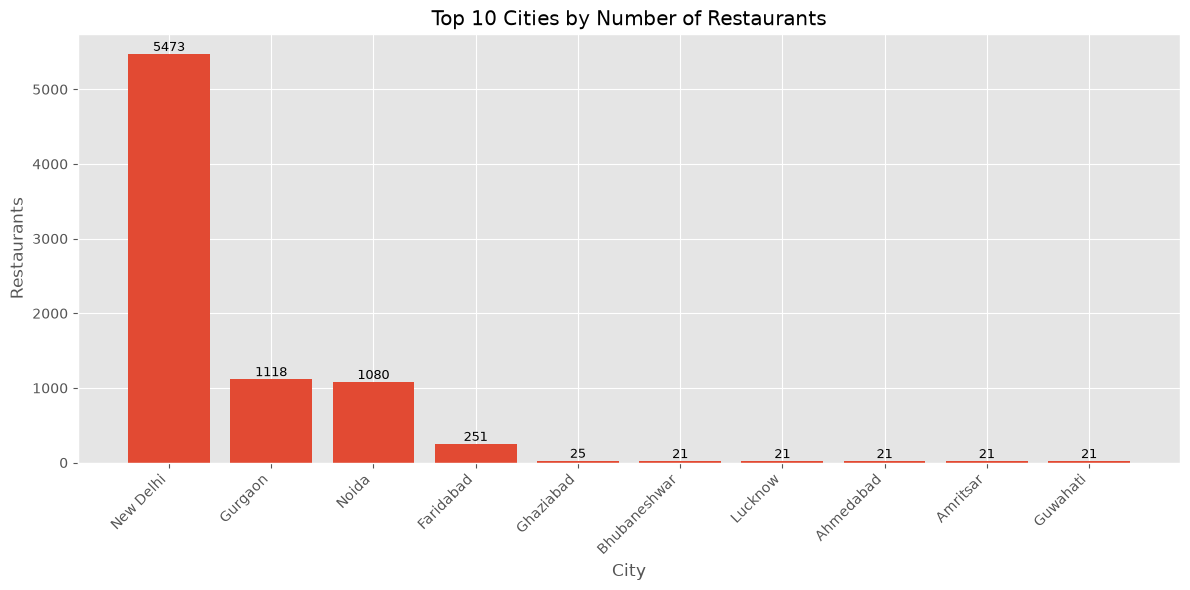

In [7]:
plt.figure(figsize=(12,6))

top10 = city_count.head(10)

bars = plt.bar(top10["City"], top10["Restaurant Count"])

plt.xticks(rotation=45, ha="right")

plt.title("Top 10 Cities by Number of Restaurants")
plt.xlabel("City")
plt.ylabel("Restaurants")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        int(bar.get_height()),
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

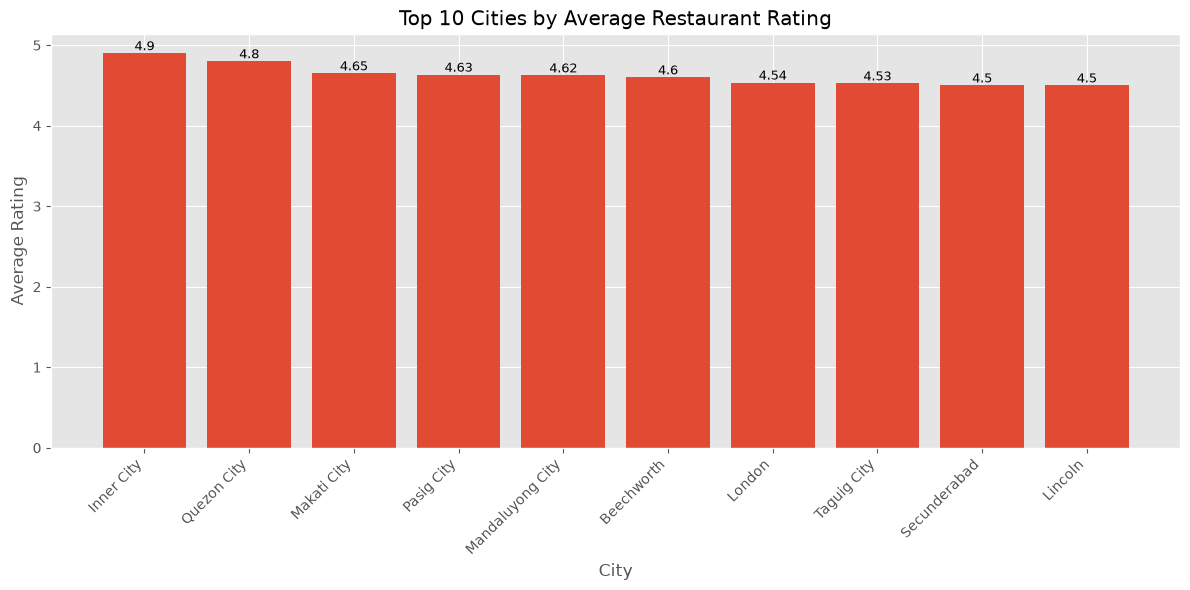

In [8]:
plt.figure(figsize=(12,6))

top_rating = city_rating.head(10)

bars = plt.bar(top_rating["City"], top_rating["Average Rating"])

plt.xticks(rotation=45, ha="right")

plt.title("Top 10 Cities by Average Restaurant Rating")
plt.xlabel("City")
plt.ylabel("Average Rating")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        round(bar.get_height(),2),
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [9]:
summary = city_count.merge(city_rating, on="City")

summary.head(10)

,City,Restaurant Count,Average Rating
0,New Delhi,5473,2.438845
1,Gurgaon,1118,2.651431
2,Noida,1080,2.036204
3,Faridabad,251,1.866932
4,Ghaziabad,25,2.852000
5,Bhubaneshwar,21,3.980952
6,Lucknow,21,4.195238
7,Ahmedabad,21,4.161905
8,Amritsar,21,3.685714
9,Guwahati,21,4.190476


# Observations

- Identified the city with the highest number of restaurants.
- Calculated the average restaurant rating for every city.
- Determined the city with the highest average rating.
- Visualized the top 10 cities by restaurant count.
- Visualized the top 10 cities by average rating.
- Compared restaurant popularity and quality across different cities.